____
# COMPUTE GRADIENT, INTERPOLATE AND ROTATE SWOT DATA ON COLOC POINTS

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

___________
# CHOOSE

In [30]:
# TO CHOOSE 
#L4_extent = 'regional_europe'
L4_extent = 'global'
drifters_sources = 'all_med_variational_10min_v0.nc'
spectral_decomp = True
dt = '12h' #'nearestswath'
#dt = '10d'
if spectral_decomp == True : drifters_sources = 'spectral_decomp_'+ drifters_sources
colocs_sources = f'{dt}_'+drifters_sources

In [31]:
ggd_variables = ['adt', 'sla', 'err_sla']

_______
# Data

In [32]:
dss = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc', 'L4_sealevel', f'L4_{L4_extent}_dt_2021_noswot.nc')).drop_vars(['lon_bnds', 'lat_bnds', 'nv'])
df = pd.read_csv(os.path.join(zarr_dir, 'drifters', f'drifterscoloc_'+colocs_sources.replace('.nc', '.csv')), dtype={'drifter_id':str}, parse_dates=['datetime'])

In [33]:
dss

<xarray.Dataset> Size: 8MB
Dimensions:         (time: 108, latitude: 32, longitude: 28)
Coordinates:
  * time            (time) datetime64[ns] 864B 2023-03-25 ... 2023-07-10
  * latitude        (latitude) float32 128B 36.12 36.38 36.62 ... 43.62 43.88
  * longitude       (longitude) float32 112B 0.125 0.375 0.625 ... 6.625 6.875
Data variables:
    crs             (time) int32 432B ...
    sla             (time, latitude, longitude) float64 774kB ...
    err_sla         (time, latitude, longitude) float64 774kB ...
    ugosa           (time, latitude, longitude) float64 774kB ...
    err_ugosa       (time, latitude, longitude) float64 774kB ...
    vgosa           (time, latitude, longitude) float64 774kB ...
    err_vgosa       (time, latitude, longitude) float64 774kB ...
    adt             (time, latitude, longitude) float64 774kB ...
    ugos            (time, latitude, longitude) float64 774kB ...
    vgos            (time, latitude, longitude) float64 774kB ...
    tpa_correction  (time) float64 864B ...
    flag_ice        (time, latitude, longitude) float64 774kB ...
Attributes: (12/44)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    summary:                         SSALTO/DUACS Delayed-Time Level-4 sea su...
    time_coverage_duration:          P1D
    time_coverage_end:               2023-01-01T12:00:00Z
    time_coverage_resolution:        P1D
    time_coverage_start:             2022-12-31T12:00:00Z
    title:                           DT merged all satellites Global Ocean Gr...

In [34]:
for ggd in ggd_variables :
    g = 9.81
    deglat_km = 111111 #m/deglat
    dlon_dx = 1/(deglat_km * np.cos(dss.latitude * np.pi / 180))
    dlat_dy = 1/deglat_km
    dss['ggde_'+ggd] = g*dss[ggd].differentiate('longitude')*dlon_dx
    dss['ggdn_'+ggd] = g*dss[ggd].differentiate('latitude')*dlat_dy
dss['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(dss.latitude * np.pi / 180)
dss['ggde_fromduacsv'] = dss.f * dss.vgos
dss['ggdn_fromduacsv'] = - dss.f * dss.ugos

lon = df.longitude.values
lat = df.latitude.values
t = pd.to_datetime(df.datetime).values
ds0 = dss.interp(longitude=('z', lon), latitude=('z',lat), time= ('z',t))
df0 = ds0.to_dataframe()
df0.index.names = ['row_number']   
df0.to_csv(os.path.join(zarr_dir, 'alti',f'L4_{L4_extent}noswot_'+colocs_sources.replace('.nc', '.csv')))

In [12]:
dss.longitude.diff('longitude')

<xarray.DataArray 'longitude' (longitude: 27)> Size: 108B
array([0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25,
       0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25,
       0.25, 0.25, 0.25, 0.25, 0.25], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 108B 0.375 0.625 0.875 ... 6.375 6.625 6.875

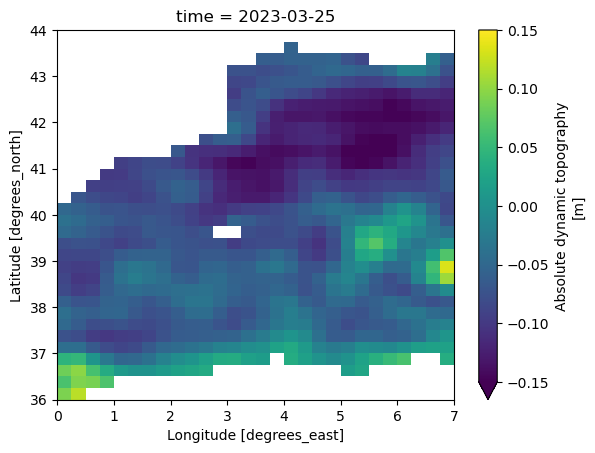

In [13]:
dss.isel(time=0).adt.plot(vmin=-0.15, vmax=0.15)

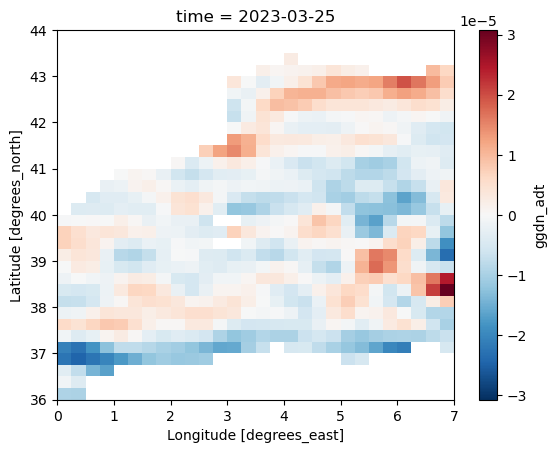

In [14]:
dss.isel(time=0).ggdn_adt.plot()

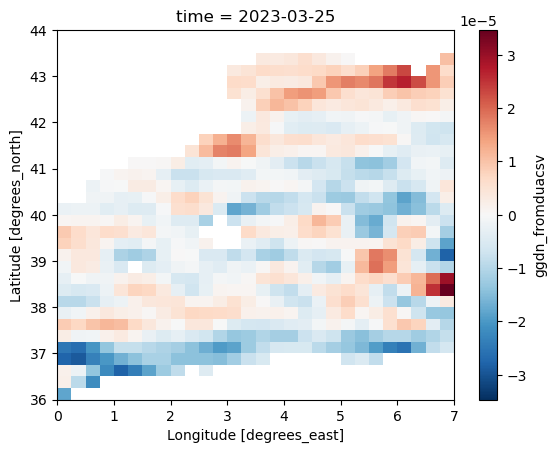

In [15]:
dss.isel(time=0).ggdn_fromduacsv.plot()

In [35]:
# TO CHOOSE 
#L4_extent = 'global'
drifters_sources = 'all_med_variational_10min_v0.nc'
spectral_decomp = True
dt = '12h' #'nearestswath'
#dt='10d'
if spectral_decomp == True : drifters_sources = 'spectral_decomp_'+ drifters_sources
colocs_sources = f'{dt}_'+drifters_sources
ggd_variables = ['adt', 'sla', 'err_sla']

In [36]:
dss = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc', 'L4_sealevel', f'L4_with_swot.nc')).drop_vars(['lon_bnds', 'lat_bnds', 'nv'])
if spectral_decomp == True : drifters_sources = 'spectral_decomp_'+ drifters_sources
df = pd.read_csv(os.path.join(zarr_dir, 'drifters', f'drifterscoloc_'+colocs_sources.replace('.nc', '.csv')), dtype={'drifter_id':str}, parse_dates=['datetime'])

In [37]:
for ggd in ggd_variables :
    g = 9.81
    deglat_km = 111111 #m/deglat
    dlon_dx = 1/(deglat_km * np.cos(dss.latitude * np.pi / 180))
    dlat_dy = 1/deglat_km
    dss['ggde_'+ggd] = g*dss[ggd].differentiate('longitude')*dlon_dx
    dss['ggdn_'+ggd] = g*dss[ggd].differentiate('latitude')*dlat_dy
dss['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(dss.latitude * np.pi / 180)
dss['ggde_fromduacsv'] = dss.f * dss.vgos
dss['ggdn_fromduacsv'] = - dss.f * dss.ugos

lon = df.longitude.values
lat = df.latitude.values
t = pd.to_datetime(df.datetime).values
ds0 = dss.interp(longitude=('z', lon), latitude=('z',lat), time= ('z',t))
df0 = ds0.to_dataframe()
df0.index.names = ['row_number']   
df0.to_csv(os.path.join(zarr_dir, 'alti',f'L4_withswot_'+colocs_sources.replace('.nc', '.csv')))

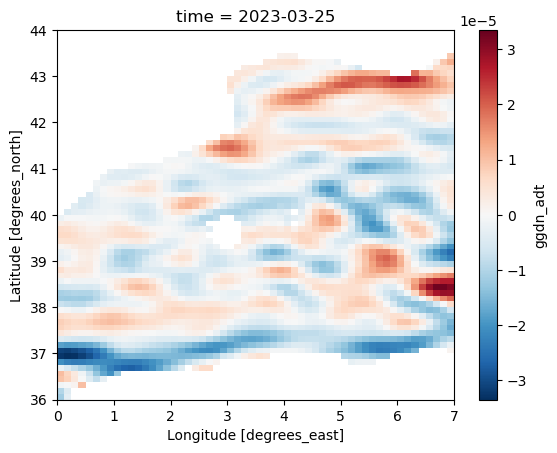

In [20]:
dss.isel(time=0).ggdn_adt.plot()